# 🛍️ Shopping Mall Customer Segmentation
## Notebook 0 — EDA & Preprocessing

---
### 📌 What is this notebook doing?
Before we can group customers, we need to:
1. **Understand** the data (EDA — Exploratory Data Analysis)
2. **Clean** the data (remove useless columns, fix encoding)
3. **Scale** the data (make all numbers in the same range)
4. **Save** the cleaned data for use by all algorithm notebooks

> ⚠️ **Run this notebook FIRST before any clustering notebooks.**

---
## Step 1: Import Libraries
We load all the tools we need before starting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
print('✅ Libraries loaded!')

✅ Libraries loaded!


---
## Step 2: Load Dataset

In [2]:
df = pd.read_csv('data/Shopping_Mall_Customer_Segmentation_Data_.csv')
print(f'Total customers : {len(df):,}')
print(f'Total features  : {df.shape[1]}')
print()
df.head(10)

Total customers : 15,079
Total features  : 5



,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76
5,7e211337-e92f-4140-8231-5c9ac7a2aa12,42,Male,158335,40
6,30661d57-eeb5-4886-970a-9c7d0f260ad8,27,Female,163501,37
7,43417ade-6b17-431e-ae76-d8ed26aa46ac,24,Male,70476,17
8,86f73b1a-6a91-4d7e-ad21-0aefcf6111cc,83,Male,47743,34
9,b20fe0a0-e254-4116-b804-5403bb2f59ea,62,Female,63448,3


---
## Step 3: Initial EDA (Quick Overview)
Check shape, types, missing values, duplicates, and quick statistics before cleaning.

In [3]:
print('--- Column Data Types ---')
df.info()
print()
print('--- Missing Values ---')
print(df.isnull().sum())
print()
print('--- Duplicate Rows ---')
print(f'Duplicates: {df.duplicated().sum()}')

--- Column Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     15079 non-null  object
 1   Age             15079 non-null  int64 
 2   Gender          15079 non-null  object
 3   Annual Income   15079 non-null  int64 
 4   Spending Score  15079 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 589.2+ KB

--- Missing Values ---
Customer ID       0
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64

--- Duplicate Rows ---
Duplicates: 0


In [4]:
print('--- Statistical Summary ---')
df.describe().round(2)

--- Statistical Summary ---


,Age,Annual Income,Spending Score
count,15079.00,15079.00,15079.00
mean,54.19,109742.88,50.59
std,21.12,52249.43,28.73
min,18.00,20022.00,1.00
25%,36.00,64141.00,26.00
50%,54.00,109190.00,51.00
75%,72.00,155008.00,75.00
max,90.00,199974.00,100.00


---
# PART 2 — Data Cleaning

### 📌 Why clean after quick EDA?
Quick EDA helps identify what needs fixing.
Now we apply cleaning in this order:
1. Handle missing values
2. Remove duplicates
3. Fix/prepare data types
4. Remove non-informative columns

### Step 4: Handle Missing Values

In [5]:
print('Missing values before handling:')
print(df.isnull().sum())
print()

if df.isnull().sum().sum() == 0:
    print('✅ No missing values found — no imputation needed.')
else:
    numeric_cols_fill = df.select_dtypes(include=np.number).columns
    categorical_cols_fill = df.select_dtypes(exclude=np.number).columns

    for col in numeric_cols_fill:
        df[col] = df[col].fillna(df[col].median())

    for col in categorical_cols_fill:
        if not df[col].mode().empty:
            df[col] = df[col].fillna(df[col].mode()[0])

    print('✅ Missing values handled using median (numeric) and mode (categorical).')

print()
print('Missing values after handling:')
print(df.isnull().sum())

Missing values before handling:
Customer ID       0
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64

✅ No missing values found — no imputation needed.

Missing values after handling:
Customer ID       0
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64


### Step 5: Remove Duplicate Rows

In [6]:
dup_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Rows before duplicate removal : {dup_before:,}')
print(f'Rows after duplicate removal  : {len(df):,}')
print(f'✅ Duplicates removed          : {dup_before - len(df):,}')

Rows before duplicate removal : 15,079
Rows after duplicate removal  : 15,079
✅ Duplicates removed          : 0


### Step 6: Drop Customer ID

In [7]:
df_clean = df.drop(columns=['Customer ID'])
print('✅ Dropped: Customer ID')
print('   Reason: UUID with no clustering value — every customer has a unique ID.')
print()
print('Remaining columns:', list(df_clean.columns))

✅ Dropped: Customer ID
   Reason: UUID with no clustering value — every customer has a unique ID.

Remaining columns: ['Age', 'Gender', 'Annual Income', 'Spending Score']


### Step 7: Encode Gender (Text -> Number)

In [8]:
le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])

print('✅ Label Encoding applied to Gender:')
for i, cls in enumerate(le.classes_):
    print(f'   {cls} → {i}')
print()
print('   Reason: Clustering algorithms only understand numbers.')
print('   Male/Female text values are converted to 0/1.')
df_clean.head(3)

# --- 按照论文标准的 10 段年龄分箱 (陈新等, 2025) ---
# 定义区间：<20, 20-25, 25-30, 30-35, 35-40, 40-45, 45-50, 50-55, 55-60, >60
# --- 年龄分箱 ---
bins = [0, 20, 25, 30, 35, 40, 45, 50, 55, 60, 100]
labels = ['<20', '20-25', '25-30', '30-35', '35-40', '40-45', '45-50', '50-55', '55-60', '>60']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# 关键改动：添加 dtype=int 确保生成的是 0/1 而不是 True/False
df_age_dummies = pd.get_dummies(df['Age_Group'], prefix='Age_Bin', dtype=int) 
df = pd.concat([df, df_age_dummies], axis=1)

# 性别转换
df['Gender_Enum'] = df['Gender'].map({'Male': 1, 'Female': 0})

# 保存
df.to_csv('data/data_full_preprocessed.csv', index=False)

✅ Label Encoding applied to Gender:
   Female → 0
   Male → 1

   Reason: Clustering algorithms only understand numbers.
   Male/Female text values are converted to 0/1.


---
# PART 3 — Full EDA (After Cleaning)

Now that data cleaning is complete, this section performs deeper analysis on cleaned data.

### Plot 1: Feature Distributions
Understand cleaned feature spreads before modeling.

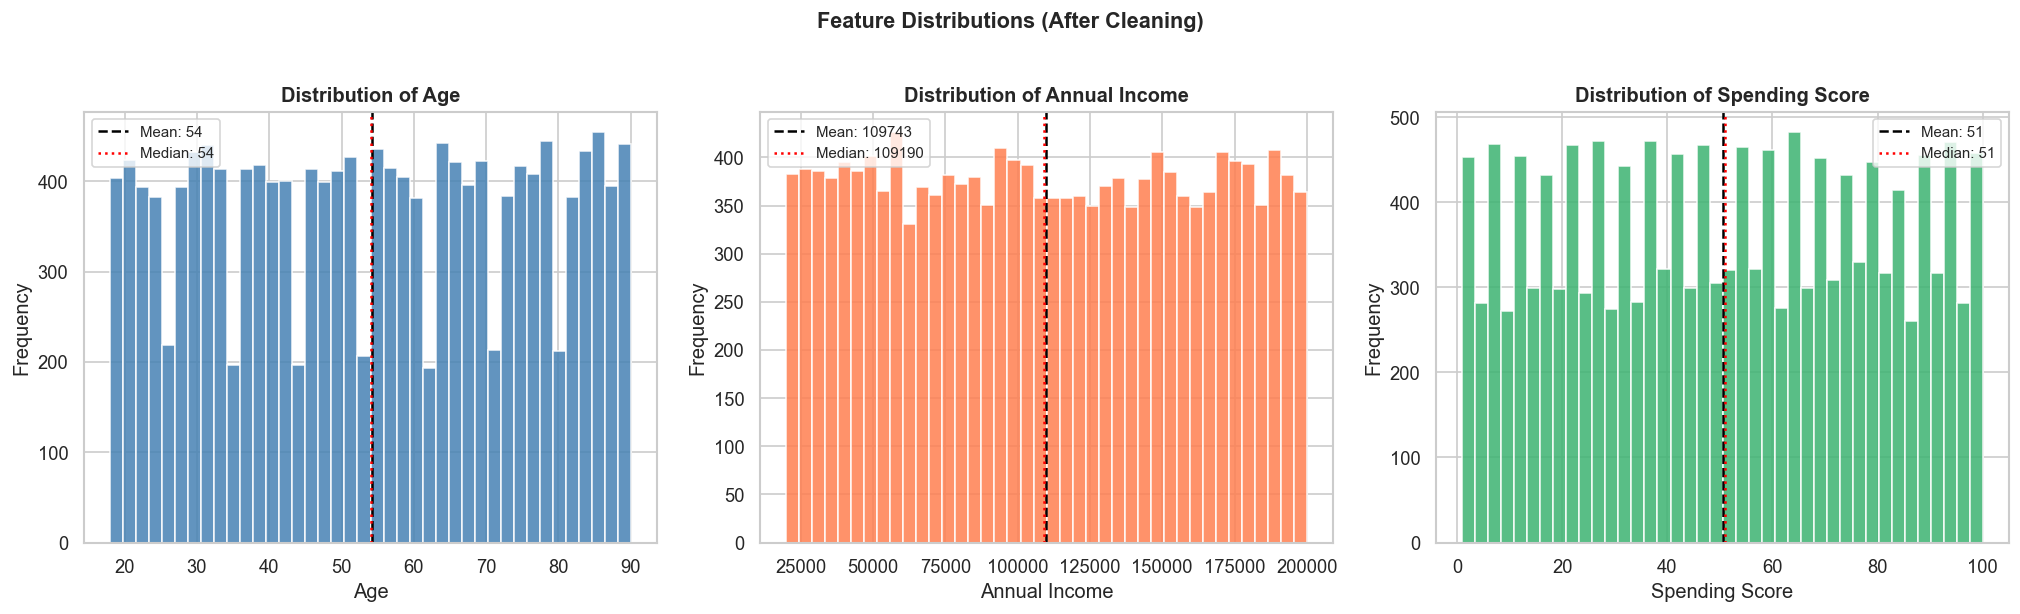

In [9]:
numeric_cols = ['Age', 'Annual Income', 'Spending Score']
colors = ['steelblue', 'coral', 'mediumseagreen']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, col, color in zip(axes, numeric_cols, colors):
    ax.hist(df_clean[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df_clean[col].mean(), color='black', linestyle='--', lw=1.5, label=f'Mean: {df_clean[col].mean():.0f}')
    ax.axvline(df_clean[col].median(), color='red', linestyle=':', lw=1.5, label=f'Median: {df_clean[col].median():.0f}')
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions (After Cleaning)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Plot 2: Gender Distribution
Check class balance and average numeric behavior by gender.

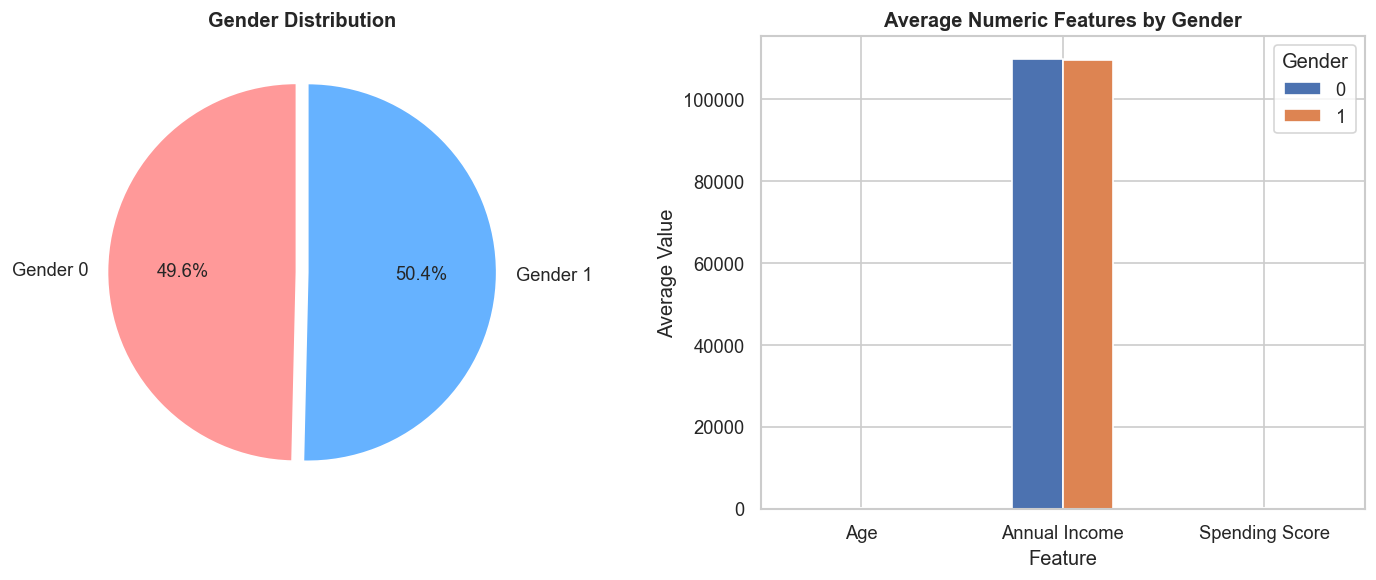

In [10]:
gender_counts = df_clean['Gender'].value_counts().sort_index()

gender_labels = [f'Gender {v}' for v in gender_counts.index]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gender_counts.plot.pie(
    ax=axes[0],
    labels=gender_labels,
    autopct='%1.1f%%',
    colors=['#FF9999', '#66B2FF'],
    startangle=90,
    explode=[0.03] * len(gender_counts),
    textprops={'fontsize': 11}
)
axes[0].set_title('Gender Distribution', fontweight='bold')
axes[0].set_ylabel('')

gender_means = df_clean.groupby('Gender')[numeric_cols].mean().round(1)
gender_means.T.plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title('Average Numeric Features by Gender', fontweight='bold')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Average Value')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Plot 3: Box Plots (Outlier Check)
Spot extreme values after cleaning.

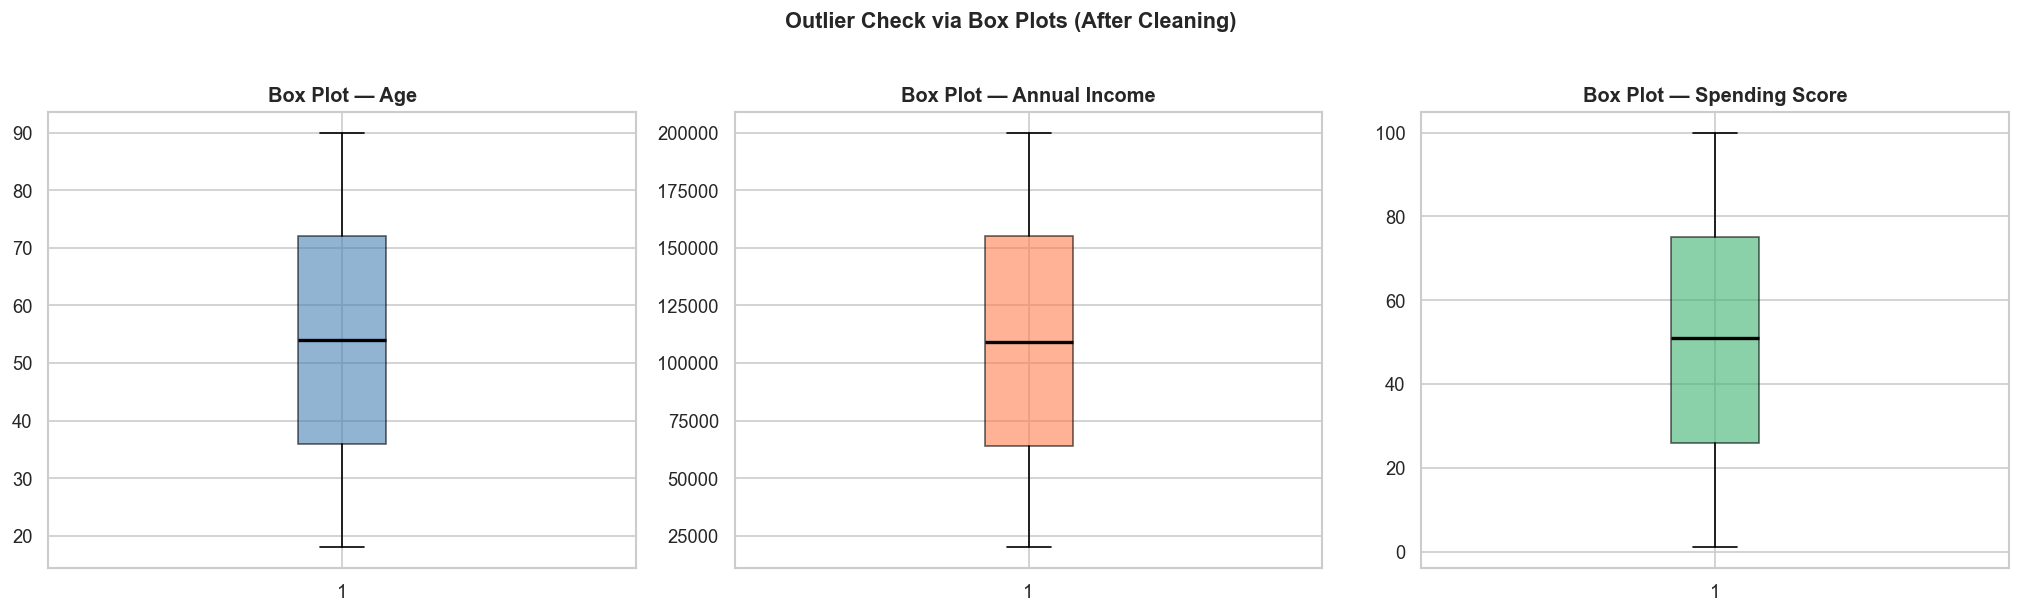

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, col, color in zip(axes, numeric_cols, colors):
    ax.boxplot(df_clean[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markersize=3, alpha=0.3))
    ax.set_title(f'Box Plot — {col}', fontweight='bold')

plt.suptitle('Outlier Check via Box Plots (After Cleaning)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Plot 5: Correlation Matrix
Check whether cleaned features are strongly related.

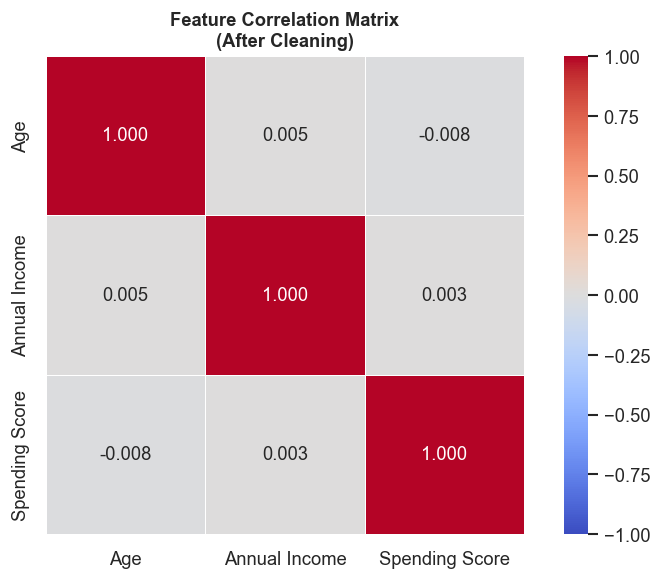

In [12]:
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, square=True,
            annot_kws={'size': 11})
plt.title('Feature Correlation Matrix\n(After Cleaning)', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

### Plot 6: Pair Plot
**Used for:** quick visual check of pairwise relationships and rough cluster separation patterns after cleaning.

It helps answer:
- Which variables separate groups better?
- Are relationships linear/non-linear?
- Are there unusual points that need attention?

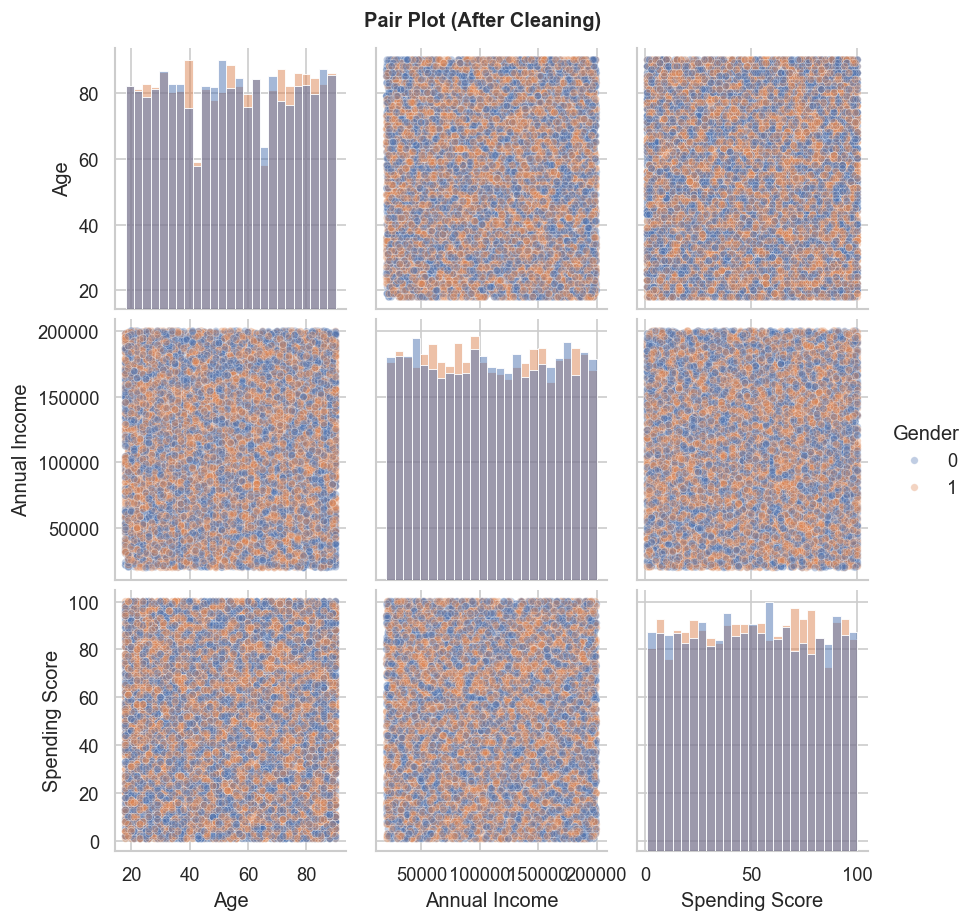

In [13]:
pairplot_cols = ['Age', 'Annual Income', 'Spending Score']
available_pairplot_cols = [col for col in pairplot_cols if col in df_clean.columns]

if len(available_pairplot_cols) >= 2:
    pairplot_df = df_clean[available_pairplot_cols + ['Gender']].copy()
    g = sns.pairplot(
        pairplot_df,
        vars=available_pairplot_cols,
        hue='Gender',
        diag_kind='hist',
        corner=False,
        plot_kws={'alpha': 0.35, 's': 20},
        height=2.5
    )
    g.fig.suptitle('Pair Plot (After Cleaning)', y=1.02, fontsize=12, fontweight='bold')
    plt.show()
else:
    print('Not enough numeric columns available for pair plot.')

### Step 8: Feature Importance (Tree-Based)
**Used for:** estimating which features most influence customer grouping.

Because clustering has no true labels, we first create temporary cluster labels with K-Means, then train:
- Decision Tree (fast, interpretable baseline)
- Random Forest (more stable importance ranking)

Decision Tree Feature Importance:


,Importance
Spending Score,0.399653
Annual Income,0.377641
Age,0.222706


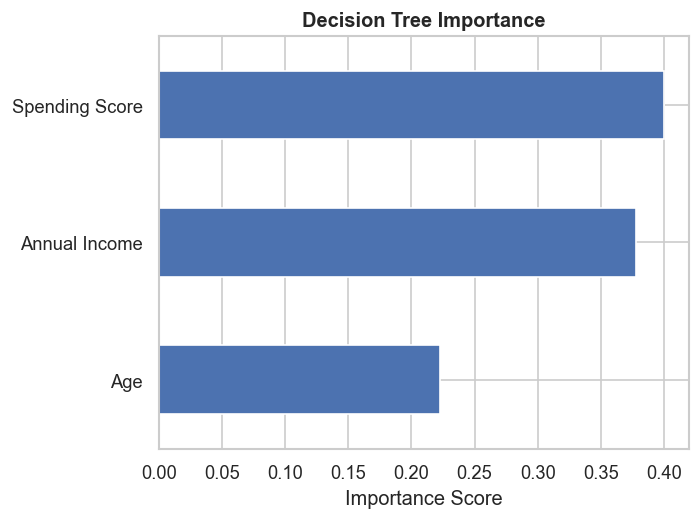

In [14]:
feature_columns = [col for col in df_clean.columns if col != 'Gender']
X_imp = df_clean[feature_columns].copy()

scaler_imp = StandardScaler()
X_imp_scaled = scaler_imp.fit_transform(X_imp)

# Use temporary K-Means labels as pseudo-targets
kmeans_temp = KMeans(n_clusters=5, random_state=42, n_init=10)
y_temp = kmeans_temp.fit_predict(X_imp_scaled)

# Decision Tree importance
tree_model = DecisionTreeClassifier(random_state=42, max_depth=4)
tree_model.fit(X_imp_scaled, y_temp)

tree_importance = pd.Series(
    tree_model.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

print('Decision Tree Feature Importance:')
display(tree_importance.to_frame(name='Importance'))

# Plot
plt.figure(figsize=(6, 4.5))
tree_importance.sort_values().plot(kind='barh')
plt.title('Decision Tree Importance', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### Optional: SHAP-Based Importance
SHAP gives local and global explanations of model behavior and is usually more interpretable.

Use it when you need detailed per-sample explanations.
For this notebook, tree and forest importance are enough for quick feature ranking.

### Step 9: Feature Scaling — StandardScaler
**Why scaling is critical for clustering:**
- Without scaling: Annual Income (20,000–200,000) vs Spending Score (1–100)
- The algorithm sees Income differences as 1000x more important than Score differences
- After scaling: both become values around -2 to +2, treated equally

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

print('Before Scaling — range of each feature:')
for col in df_clean.columns:
    print(f'   {col:20s}: min={df_clean[col].min():.1f}, max={df_clean[col].max():.1f}')

df_scaled_check = pd.DataFrame(X_scaled, columns=df_clean.columns)
print()
print('After Scaling — all features now have mean≈0, std≈1:')
for col in df_scaled_check.columns:
    print(f'   {col:20s}: mean={df_scaled_check[col].mean():.3f}, std={df_scaled_check[col].std():.3f}')

Before Scaling — range of each feature:
   Age                 : min=18.0, max=90.0
   Gender              : min=0.0, max=1.0
   Annual Income       : min=20022.0, max=199974.0
   Spending Score      : min=1.0, max=100.0

After Scaling — all features now have mean≈0, std≈1:
   Age                 : mean=-0.000, std=1.000
   Gender              : mean=-0.000, std=1.000
   Annual Income       : mean=-0.000, std=1.000
   Spending Score      : mean=-0.000, std=1.000


### Plot 7: Before vs After Scaling
**Purpose:** Visually prove that scaling worked — all features now have the same range.

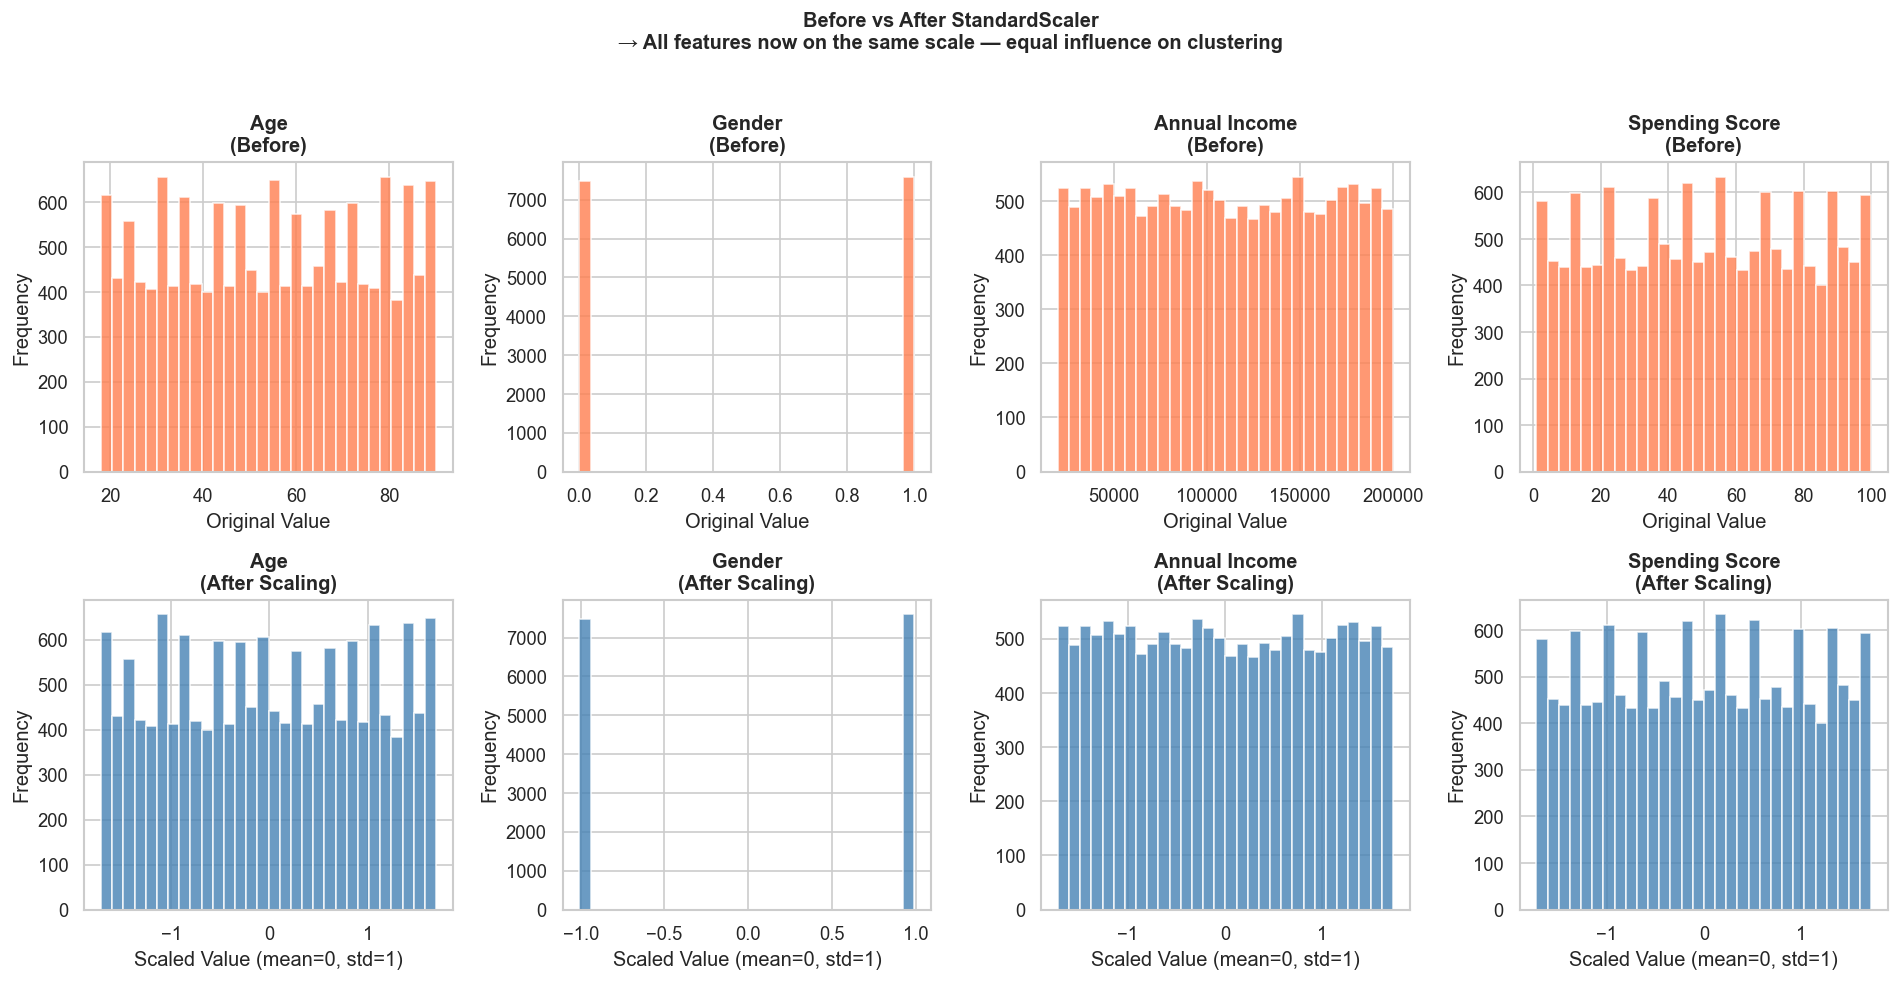

📊 Interpretation:
   Top row  = original values (very different ranges)
   Bottom row = scaled values (all centred around 0)
   → Now all features have EQUAL influence on the clustering algorithm.


In [16]:
all_cols = df_clean.columns.tolist()
n_cols = len(all_cols)
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 8))

for i, col in enumerate(all_cols):
    axes[0, i].hist(df_clean[col], bins=30, color='coral', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col}\n(Before)', fontweight='bold')
    axes[0, i].set_xlabel('Original Value')
    axes[0, i].set_ylabel('Frequency')

    axes[1, i].hist(df_scaled_check[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'{col}\n(After Scaling)', fontweight='bold')
    axes[1, i].set_xlabel('Scaled Value (mean=0, std=1)')
    axes[1, i].set_ylabel('Frequency')

plt.suptitle('Before vs After StandardScaler\n→ All features now on the same scale — equal influence on clustering',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/eda_scaling.png', bbox_inches='tight')
plt.show()
print('📊 Interpretation:')
print('   Top row  = original values (very different ranges)')
print('   Bottom row = scaled values (all centred around 0)')
print('   → Now all features have EQUAL influence on the clustering algorithm.')

### Step 10: Save Preprocessed Data
We save two files:
- `data_preprocessed.csv` — the cleaned data (for reference and cluster profiling)
- `X_scaled.npy` — the scaled array (this is what the algorithms actually train on)

In [17]:
df_clean.to_csv('data/data_preprocessed.csv', index=False)
np.save('data/X_scaled.npy', X_scaled)
df.to_csv('data/data_full_preprocessed.csv', index=False)

print('✅ Saved: data_preprocessed.csv  — cleaned data for cluster profiling')
print('✅ Saved: X_scaled.npy           — scaled array for clustering algorithms')
print()
print('These files will be loaded by:')
print('  → member1_kmeans.ipynb')
print('  → member2_meanshift.ipynb')
print('  → member3_dbscan.ipynb')
print('  → member4_autoencoder.ipynb')
print('  → comparison_all_methods.ipynb')

✅ Saved: data_preprocessed.csv  — cleaned data for cluster profiling
✅ Saved: X_scaled.npy           — scaled array for clustering algorithms

These files will be loaded by:
  → member1_kmeans.ipynb
  → member2_meanshift.ipynb
  → member3_dbscan.ipynb
  → member4_autoencoder.ipynb
  → comparison_all_methods.ipynb


---
## Workflow Summary

| Stage | Actions | Result |
|------|--------|--------|
| 1. Initial EDA (Quick) | Shape, types, missing, duplicates, stats | Problems identified early |
| 2. Data Cleaning | Missing handled, duplicates removed, ID dropped, gender encoded | Data is clean and model-ready |
| 3. Full EDA (After Cleaning) | Distribution, gender view, outlier check, relationships, correlation, pair plot | Insights extracted from cleaned data |
| 4. Importance + Prep | Tree-based feature importance, scaling, output files | Ready for clustering notebooks |

**Ready to cluster.** Proceed to the algorithm notebooks.